## Step 1: Library Imports

| Library              | Alias | Purpose & Key Uses in Data Analysis |
|----------------------|-------|-------------------------------------|
| **os**              | (None) | Handles operating system interactions, like file paths, directories, and environment variables. Useful for loading data files dynamically (e.g., `os.path.join()` for cross-platform paths). |
| **pandas**          | `pd`  | Core library for data manipulation and analysis. Handles DataFrames for cleaning, filtering, grouping, and merging datasets (e.g., `pd.read_csv()`). |
| **numpy**           | `np`  | Fundamental package for numerical computing. Provides arrays, mathematical functions, and random number generation (e.g., `np.array()`, linear algebra ops). |
| **matplotlib.pyplot** | `plt` | Base plotting library for creating static, interactive, and animated visualizations. Low-level control for custom charts (e.g., `plt.plot()`). |
| **seaborn**         | `sns` | High-level interface for statistical graphics built on Matplotlib. Great for quick, attractive plots like heatmaps and pairplots (e.g., `sns.heatmap()`). |
| **statsmodels**     | `sm`  | Tools for estimating statistical models, conducting tests, and performing time-series analysis (e.g., OLS regression with `sm.OLS()`). |
| **plotly.express**  | `px`  | Simplified interface for creating interactive plots (e.g., scatter plots, dashboards). Ideal for web-friendly visuals that zoom/pan. |
| **scipy.stats**     | `stats` | Statistical functions from SciPy, including hypothesis tests, distributions, and correlation (e.g., `stats.ttest_ind()` for t-tests). |
| **openpyxl**        | (None) | Reads/writes Excel files (.xlsx). Useful for importing/exporting data without Excel installed (e.g., `pd.read_excel()` under the hood). |
| **warnings**        | (None) | Suppresses warning messages during execution (e.g., deprecation notices). Set to `'ignore'` to keep output clean—use sparingly in production! |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import plotly.express as px
from scipy import stats
import openpyxl
import warnings
warnings.filterwarnings('ignore')

## Step 2: Data Loading

- In this step, we load the Global Superstore Sales dataset into a pandas DataFrame for analysis.

- The dataset is read using `pd.read_csv()` from the file `'Global_Superstore2.csv'`.

- Since the file contains special characters (e.g., in customer names or locations), the **`latin1` encoding** is used to avoid `UnicodeDecodeError` during loading.

In [2]:
df = pd.read_csv('Global_Superstore2.csv',encoding='latin1')

## Step 3: Data Understanding

In this step, we explore the dataset's structure, quality, and key stats using basic Pandas functions. This reveals a clean dataset (no duplicates) with 51,290 orders across 24 columns, but note the high missing rate in `Postal Code` (~80%) and string-formatted dates (convert them next for time analysis).

**Quick Insights**:
- **Size**: 51,290 rows × 24 columns.
- **Quality**: 0 duplicates; only `Postal Code` has misses (41,296 nulls).
- **Types**: 17 strings (e.g., IDs, names), 7 numerics (e.g., Sales: float64, mean $246, range $0.44–$22,638).
- **Notable Stats**: Profit mean $28.61 (but dips to -$6,600—watch for losses); Quantity avg. 3.5 (max 14).


### Step 3.1: Sample Data & Dataset Dimensions

To begin understanding the dataset, we preview the first few rows and check its overall shape.

**Observations from the first 5 rows:**
- Each row represents a **single product order** with customer, product, and shipping details.
- Key types of information included:
  - **Order details:** `Order ID`, `Order Date`, `Ship Date`, `Ship Mode`, `Order Priority`
  - **Customer info:** `Customer ID`, `Customer Name`, `Segment`, `City`, `State`, `Country`
  - **Product info:** `Product ID`, `Category`, `Sub-Category`, `Product Name`
  - **Sales metrics:** `Sales`, `Quantity`, `Discount`, `Profit`, `Shipping Cost`
- Dataset appears **well-structured**, and each order contains a single product record.

**Dataset Dimensions:**
- Number of rows: **51,290**  
- Number of columns: **24**  


In [3]:
print(df.head(5))
print('--'*60)
print(df.shape)

   Row ID         Order ID  Order Date   Ship Date     Ship Mode Customer ID  \
0   32298   CA-2012-124891  31-07-2012  31-07-2012      Same Day    RH-19495   
1   26341    IN-2013-77878  05-02-2013  07-02-2013  Second Class    JR-16210   
2   25330    IN-2013-71249  17-10-2013  18-10-2013   First Class    CR-12730   
3   13524  ES-2013-1579342  28-01-2013  30-01-2013   First Class    KM-16375   
4   47221     SG-2013-4320  05-11-2013  06-11-2013      Same Day     RH-9495   

      Customer Name      Segment           City            State  ...  \
0       Rick Hansen     Consumer  New York City         New York  ...   
1     Justin Ritter    Corporate     Wollongong  New South Wales  ...   
2      Craig Reiter     Consumer       Brisbane       Queensland  ...   
3  Katherine Murray  Home Office         Berlin           Berlin  ...   
4       Rick Hansen     Consumer          Dakar            Dakar  ...   

         Product ID    Category Sub-Category  \
0   TEC-AC-10003033  Technology 

### 3.2: Columns, Missing Values, & Duplicate Records

In this step, we examine the dataset’s structure by reviewing column names, checking for missing values, and identifying duplicate records. This helps assess overall data quality before preprocessing.

**Columns Overview:**  
The dataset contains **24 columns** spanning order details, customer information, product attributes, and sales metrics.

- **Order & Shipping:** Row ID, Order ID, Order Date, Ship Date, Ship Mode, Order Priority  
- **Customer:** Customer ID, Customer Name, Segment  
- **Geography:** City, State, Country, Postal Code, Market, Region  
- **Product:** Product ID, Category, Sub-Category, Product Name  
- **Sales Metrics:** Sales, Quantity, Discount, Profit, Shipping Cost

**Missing Values:**  
- All columns are complete **except `Postal Code`**, which contains **41,296 missing values (~80%)**.  
- This is expected for certain regions and will be evaluated during data cleaning.

**Duplicate Records:**  
- No duplicate rows were found, indicating each record represents a unique transaction.


In [4]:
print(df.columns)
print('--'*50)
print(df.isnull().sum())
print('--'*50)
print(df.duplicated().sum())

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='str')
----------------------------------------------------------------------------------------------------
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cos

### 3.3: Data Types & Dataset Information

In this step, we analyze the **data types** of each column and review the overall dataset summary using `df.dtypes` and `df.info()`.  
This helps verify whether features are stored in appropriate formats and highlights potential preprocessing needs.

**Data Types Overview:**
- The dataset contains a mix of **categorical (string)** and **numerical** variables.
- **17 columns** are of type `string`, including IDs, names, locations, and categories.
- **7 columns** are numerical:
  - **Integer (`int64`)**: `Row ID`, `Quantity`
  - **Float (`float64`)**: `Sales`, `Discount`, `Profit`, `Shipping Cost`, `Postal Code`

**Key Observations:**
- `Order Date` and `Ship Date` are currently stored as **strings** and will need conversion to `datetime` format for time-based analysis.
- `Postal Code` is stored as `float64` due to missing values.
- Memory usage is approximately **9.4 MB**, indicating the dataset is manageable and efficient to work with.


In [5]:
print(df.dtypes)
print(df.info())

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Postal Code       float64
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  st

### 3.4: Numerical Summary

In this step, we analyze the **statistical distribution** of numerical features using `df.describe()`.  
This provides insights into central tendency, spread, and the presence of extreme values in key metrics.

**Key Numerical Features Analyzed:**
- Sales
- Quantity
- Discount
- Profit
- Shipping Cost
- Row ID
- Postal Code

**Key Observations:**
- **Sales**:
  - Average sales per order ≈ **246**
  - Wide range from **0.44 to 22,638**, indicating the presence of both small and high-value orders
- **Profit**:
  - Mean profit ≈ **28.61**
  - Minimum profit reaches **−6,600**, indicating loss-making transactions that may need further investigation
- **Quantity**:
  - Average quantity ordered ≈ **3.5 units**
  - Maximum quantity is **14 units**
- **Discount**:
  - Mean discount ≈ **0.14**
  - Maximum discount of **0.85**, which may significantly impact profitability
- **Shipping Cost**:
  - Ranges from **0 to 933.57**, showing high variability across regions and shipping modes

**Insight:**  
The numerical summary reveals a **right-skewed distribution** for sales and profit, with a small number of high-value transactions.  
Negative profits and high discounts highlight areas to explore further during analysis.



In [6]:
print(df.describe())

            Row ID   Postal Code         Sales      Quantity      Discount  \
count  51290.00000   9994.000000  51290.000000  51290.000000  51290.000000   
mean   25645.50000  55190.379428    246.490581      3.476545      0.142908   
std    14806.29199  32063.693350    487.565361      2.278766      0.212280   
min        1.00000   1040.000000      0.444000      1.000000      0.000000   
25%    12823.25000  23223.000000     30.758625      2.000000      0.000000   
50%    25645.50000  56430.500000     85.053000      3.000000      0.000000   
75%    38467.75000  90008.000000    251.053200      5.000000      0.200000   
max    51290.00000  99301.000000  22638.480000     14.000000      0.850000   

             Profit  Shipping Cost  
count  51290.000000   51290.000000  
mean      28.610982      26.375915  
std      174.340972      57.296804  
min    -6599.978000       0.000000  
25%        0.000000       2.610000  
50%        9.240000       7.790000  
75%       36.810000      24.450000  
m

## Step 4: 📊 Data Cleaning

Data cleaning is a crucial step to ensure the dataset is accurate, consistent, and ready for analysis or modeling. This step involves handling missing values, correcting data types, and optimizing memory usage.

### 4.1:📌 Converting Columns to Categorical Data Type in Pandas
🔍 Objective

- The goal of this step is to optimize memory usage and improve performance by converting selected string-based columns into the category data type using Pandas.

🧠 Explanation

- A list named category_cols is created containing all columns that represent categorical (non-numeric) information.

- A for loop iterates through each column name in the list.

- Each column is converted to the category data type using astype('category').

In [ ]:
category_cols=['Ship Mode','Customer Name','Segment','City','State','Country','Market','Region','Category','Sub-Category','Order Priority']

for col in category_cols:
    df[col]=df[col].astype('category')

### 4.2: 📌 Handling Missing Values in Postal Code Column
🔍 Objective

- Fill missing values in the Postal Code column to ensure the dataset has no null values, which prevents errors during analysis.

🧠 Explanation

- The fillna() function replaces all NaN (missing) values in the Postal Code column with 0.

- Ensures the column contains complete data for further processing or analysis.

In [9]:
df['Postal Code']=df['Postal Code'].fillna(0)

### 4.3: 📌 Converting Postal Code Column to Integer
🔍 Objective

- Convert the Postal Code column to integer type for consistent data type usage and efficient computations.

🧠 Explanation

- The astype('int64') function changes the column from float (after filling NaNs) to integer.

- Ensures numerical operations and comparisons can be performed without errors.

In [10]:
df['Postal Code']=df['Postal Code'].astype('int64')

### 4.4: 📌 Converting Date Columns to Datetime Format
🔍 Objective

- Convert the Order Date and Ship Date columns to datetime format to enable time-based analysis and calculations.

🧠 Explanation

- pd.to_datetime() converts string date columns into datetime objects in Pandas.

- This allows performing date operations like calculating delivery time, filtering by year/month, or plotting time series.

- Note: format specifies the date format in the column to ensure correct parsing.

In [ ]:
df['Order Date']=pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date']=pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

# Step 5: Exploratory Data Analysis (EDA)

- Objective:
    - To explore the dataset, understand distributions, relationships, and patterns among variables to guide further analysis and modeling.

## 5.1: 🔎 Univariate Analysis

- Univariate analysis examines one variable at a time to understand its distribution, central tendency, and spread. It helps identify patterns, outliers, and data quality issues.

### 5.1.1: 📌 Categorical Columns – Value Counts and Percentage Distribution
🔍 Objective

- Analyze the distribution of categorical columns to understand the dataset better.

- Get both absolute counts and percentage proportions for each category

🧠 Explanation

- value_counts() shows the number of occurrences for each category in a column.

- value_counts(normalize=True) * 100 calculates the percentage distribution of each category.

- Looping through cat_cols ensures all important categorical columns are analyzed systematically.

In [12]:
cat_cols=['Ship Mode','Segment','Market','Region','Category','Sub-Category','Order Priority']
for col in cat_cols:
    print(f'\nColumns:{col}')
    print(df[col].value_counts())
    print((df[col].value_counts(normalize=True)*100).round(2))
    print('--'*50)    


Columns:Ship Mode
Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64
Ship Mode
Standard Class    60.00
Second Class      20.10
First Class       14.63
Same Day           5.27
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------

Columns:Segment
Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64
Segment
Consumer       51.70
Corporate      30.08
Home Office    18.22
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------

Columns:Market
Market
APAC      11002
LATAM     10294
EU        10000
US         9994
EMEA       5029
Africa     4587
Canada      384
Name: count, dtype: int64
Market
APAC      21.45
LATAM     20.07
EU        19.50
US        19.49
EMEA       9.81
Africa     8.94
Canada     0.75
Name: prop

### 5.1.2: 📌 Numerical Columns – Descriptive Statistics
🔍 Objective

- Summarize the numerical columns to understand central tendency, dispersion, and range.

- Obtain key statistics like count, mean, standard deviation, min, max, and quartiles

🧠 Explanation

- describe() provides summary statistics for each numerical column.

- Includes:

    - count: Number of non-null values

    - mean: Average value

    - std: Standard deviation (spread of the data)

    - min / max: Minimum and maximum values

    - 25%, 50%, 75%: Quartiles (distribution insights)

    - Looping through num_cols ensures all relevant numerical columns are analyzed systematically.

In [13]:
num_cols=['Sales','Quantity','Discount','Profit','Shipping Cost']
for col in num_cols:
    print(f'\nColumn:{col}')
    print(df[col].describe())
    print('--'*50)


Column:Sales
count    51290.000000
mean       246.490581
std        487.565361
min          0.444000
25%         30.758625
50%         85.053000
75%        251.053200
max      22638.480000
Name: Sales, dtype: float64
----------------------------------------------------------------------------------------------------

Column:Quantity
count    51290.000000
mean         3.476545
std          2.278766
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         14.000000
Name: Quantity, dtype: float64
----------------------------------------------------------------------------------------------------

Column:Discount
count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: Discount, dtype: float64
----------------------------------------------------------------------------------------------------

Column:Profit
count    51290.0

## 5.2: 📌 Bivariate Analysis

- Bivariate analysis helps us understand the relationship between two variables—whether categorical, numerical, or mixed.

### 5.2.1: 📌 Categorical vs Numerical Columns
🔍 Objective

- Analyze the relationship between categorical and numerical columns.

- Understand how numerical metrics vary across different categories.

- Helps identify patterns, trends, or anomalies in the dataset.

🧠 Explanation

- Grouping by categorical columns using groupby(cat) allows computation of numerical summaries for each category.

- mean() calculates the average value of numerical columns for each category.

- .round(2) ensures results are easily readable with 2 decimal places.

- Sorting (sort_values) highlights highest to lowest averages, helping to identify key patterns.

- Looping through cat_cols and num_cols ensures all combinations of categorical and numerical columns are analyzed systematically.

In [14]:
# find mean 
cat_cols=['Ship Mode','Segment','Market','Region','Category','Sub-Category','Order Priority']
num_cols=['Sales','Quantity','Discount','Profit','Shipping Cost']

for cat in cat_cols:
    for num in num_cols:
        print(f'\nRelationship: {cat} vs {num}')
        print(df.groupby(cat)[num].mean().round(2).sort_values(ascending=False))
        print('--'*50)


Relationship: Ship Mode vs Sales
Ship Mode
Second Class      248.88
Same Day          247.02
Standard Class    246.26
First Class       243.97
Name: Sales, dtype: float64
----------------------------------------------------------------------------------------------------

Relationship: Ship Mode vs Quantity
Ship Mode
Standard Class    3.49
First Class       3.47
Second Class      3.47
Same Day          3.42
Name: Quantity, dtype: float64
----------------------------------------------------------------------------------------------------

Relationship: Ship Mode vs Discount
Ship Mode
First Class       0.15
Same Day          0.14
Second Class      0.14
Standard Class    0.14
Name: Discount, dtype: float64
----------------------------------------------------------------------------------------------------

Relationship: Ship Mode vs Profit
Ship Mode
Standard Class    28.94
Second Class      28.38
Same Day          28.20
First Class       27.73
Name: Profit, dtype: float64
---------------

### 5.2.2: 📌 Categorical vs Categorical Columns
🔍 Objective

- Analyze the relationship between categorical columns to understand inter-category dependencies.

- Helps identify patterns, correlations, and associations between different categorical features.

- Useful for segmenting data, detecting potential biases, or understanding customer behavior.

🧠 Explanation

- pd.crosstab() computes a cross-tabulation table showing frequency counts between two categorical columns.

- Looping through cat_cols with a nested loop ensures all pairs of categorical columns are analyzed systematically.

- Results help identify:

    - Which categories co-occur frequently

    - Patterns like preferred shipping methods per segment

    - Distribution of product categories across regions or markets

    - Relationship between order priority and other categorical features

🔎 Insights (Example Observations)

- Ship Mode vs Segment: Standard Class is most common across all segments, while Same Day is least used.

- Market vs Region: Certain regions (like Central, North Asia) are dominated by specific markets (APAC, EU).

- Category vs Sub-Category: Sub-categories like Binders and Chairs belong only to specific main categories.

- Order Priority: High and Medium priority orders vary significantly across segments, categories, and shipping modes.

In [15]:
cat_cols=['Ship Mode','Segment','Market','Region','Category','Sub-Category','Order Priority']

for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        print(f'\nRelationship: {cat_cols[i]} vs {cat_cols[j]}')
        print(pd.crosstab(df[cat_cols[i]], df[cat_cols[j]]))
        print('--'*50)



Relationship: Ship Mode vs Segment
Segment         Consumer  Corporate  Home Office
Ship Mode                                       
First Class         3918       2245         1342
Same Day            1467        728          506
Second Class        5257       3198         1854
Standard Class     15876       9258         5641
----------------------------------------------------------------------------------------------------

Relationship: Ship Mode vs Market
Market          APAC  Africa  Canada  EMEA    EU  LATAM    US
Ship Mode                                                    
First Class     1585     679      70   700  1454   1479  1538
Same Day         535     257      29   300   516    521   543
Second Class    2212     992      91   993  1976   2100  1945
Standard Class  6670    2659     194  3036  6054   6194  5968
----------------------------------------------------------------------------------------------------

Relationship: Ship Mode vs Region
Region          Africa  Ca

### 5.2.3: 📌 Numerical vs Numerical Columns
🔍 Objective

- Analyze relationships between numerical variables to identify correlations.

- Helps in understanding how numerical features influence each other.

- Useful for feature selection, detecting multicollinearity, and informing modeling decisions.

🧠 Explanation

- df[num_cols].corr() calculates the Pearson correlation coefficient between each pair of numerical columns.

- Correlation values range from -1 to 1:

    - 1 → perfect positive correlation

    - 0 → no correlation

    - -1 → perfect negative correlation

- Helps to identify:

    - Strong positive relationships (e.g., Sales vs Shipping Cost)

    - Negative relationships (e.g., Discount vs Profit)

    - Weak or no relationships (e.g., Quantity vs Discount)

🔎 Insights

- Sales & Shipping Cost: Strong positive correlation (0.77), as higher sales often incur higher shipping costs.

- Profit & Discount: Negative correlation (-0.32), indicating higher discounts reduce profit.

- Sales & Profit: Moderate positive correlation (0.48), showing that higher sales generally lead to higher profit.

- Quantity & Discount: Almost no correlation (-0.02), indicating quantity ordered is independent of discount given.

In [16]:
num_cols=['Sales','Quantity','Discount','Profit','Shipping Cost']
print('Correlation Matrix for Numerical Variables')
print(df[num_cols].corr())

Correlation Matrix for Numerical Variables
                  Sales  Quantity  Discount    Profit  Shipping Cost
Sales          1.000000  0.313577 -0.086722  0.484918       0.768073
Quantity       0.313577  1.000000 -0.019875  0.104365       0.272649
Discount      -0.086722 -0.019875  1.000000 -0.316490      -0.079056
Profit         0.484918  0.104365 -0.316490  1.000000       0.354441
Shipping Cost  0.768073  0.272649 -0.079056  0.354441       1.000000


### 5.2.4: 📌 Correlation Heatmap for Numerical Variables
🔍 Objective

- Visualize the relationships between numerical variables using a heatmap.

- Helps quickly identify strong positive/negative correlations and patterns among numeric features.

- Useful for feature selection and understanding interdependencies.

🧠 Explanation

- df[num_cols].corr() computes the Pearson correlation between numerical variables.

- sns.heatmap() visually represents these correlations:

    - Red shades → strong positive correlation

    - Blue shades → strong negative correlation

    - Lighter shades → weak or no correlation

- annot=True displays the correlation values on the heatmap.

- figsize ensures the plot is wide enough for readability.

🔎 Insights

- Sales & Shipping Cost: Strong positive correlation, confirming higher sales lead to higher shipping costs.

- Profit & Discount: Negative correlation, indicating higher discounts reduce profit.

- Sales & Profit: Moderate positive correlation, reflecting that larger sales generally increase profit.

- Quantity vs Discount: Close to zero correlation, showing no clear relationship.

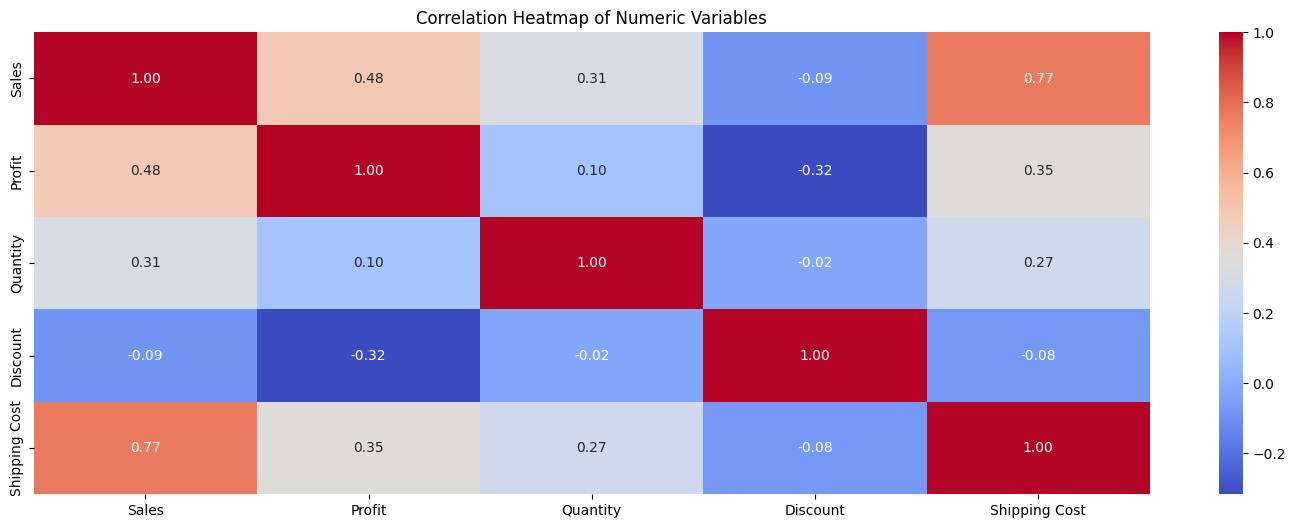

In [17]:
num_cols = ['Sales','Profit','Quantity','Discount','Shipping Cost']
corr_matrix=df[num_cols].corr()
plt.figure(figsize=(18,6))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',cbar=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

### 5.2.5: 📌 Top 10 Countries by Sales
🔍 Objective

- Identify the countries contributing the most to sales.

- Helps understand geographical revenue distribution and market focus.

🧠 Explanation

- groupby('Country')['Sales'].sum() calculates total sales per country.

- sort_values(ascending=False) sorts countries in descending order of sales.

- head(10) selects the top 10 countries by sales.

🔎 Insights

- United States leads with the highest sales (~2.3 million).

- Australia, France, and China also contribute significantly, with sales ranging from ~0.7M to 0.9M.

- Emerging markets like India, Mexico, and Brazil are among the top 10, showing potential for growth.

In [18]:
Top_countires_by_sales=df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)
print(Top_countires_by_sales)

Country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: Sales, dtype: float64


### 5.2.6: 📌 Top 10 Countries by Profit
🔍 Objective

- Identify the countries generating the highest profit.

- Helps in understanding most profitable markets and strategic focus areas.

🧠 Explanation

- groupby('Country')['Profit'].sum() calculates total profit per country.

- sort_values(ascending=False) sorts countries in descending order of profit.

- head(10) selects the top 10 most profitable countries.

- .round(2) rounds the profit values to two decimal places for readability.

🔎 Insights

- United States is the most profitable market, generating ~286K in profit.

- China and India follow, highlighting their high-revenue potential.

- European markets like UK, France, and Germany are also among the top contributors.

- Emerging markets like Mexico and El Salvador make the top 10, showing profit opportunities outside the major markets.

In [19]:
Top_countires_by_profit=df.groupby('Country')['Profit'].sum().sort_values(ascending=False).head(10).round(2)
print(Top_countires_by_profit)

Country
United States     286397.02
China             150683.08
India             129071.84
United Kingdom    111900.15
France            109029.00
Germany           107322.82
Australia         103907.43
Mexico            102818.10
Spain              54390.12
El Salvador        42023.24
Name: Profit, dtype: float64


## 5.3: 📌 Multivariate Analysis

- Multivariate analysis helps us understand relationships between three or more variables simultaneously.
- This is useful for uncovering interactions, trends, and patterns that are not visible in univariate or bivariate analysis.

### 5.3.1: Pivot Table – Ship Mode vs Category vs Sales
🔍 Objective

- Analyze how average sales vary across Ship Mode and Category simultaneously.

- Identify which Ship Mode–Category combinations generate the highest sales.

🧠 Explanation

- pd.pivot_table() allows summarizing numerical data (Sales) based on multiple categorical variables (Ship Mode, Category).

- aggfunc='mean' calculates the average sales for each combination of Ship Mode and Category.

- This helps uncover patterns, like which shipping method and product category combinations are performing best.

In [20]:
pd.pivot_table(df,values='Sales',index=['Ship Mode', 'Category'],aggfunc='mean')

Sales
Ship Mode      Category                   
First Class    Furniture        410.588620
               Office Supplies  121.238165
               Technology       464.749824
Same Day       Furniture        393.433729
               Office Supplies  117.291198
               Technology       522.924505
Second Class   Furniture        415.406714
               Office Supplies  126.966427
               Technology       466.436525
Standard Class Furniture        419.825285
               Office Supplies  119.421546
               Technology       464.418133

### 5.3.2: Pivot Table – Segment vs Region vs Profit
🔍 Objective

- Examine how median profit varies across Segment and Region simultaneously.

- Identify combinations of customer segment and region that are most and least profitable.

🧠 Explanation

- pd.pivot_table() is used to aggregate numerical data (Profit) across multiple categorical variables (Segment, Region).

- aggfunc='median' calculates the median profit for each combination, providing a robust measure of central tendency that reduces the impact of outliers.

- This helps identify Segment–Region combinations that perform well or poorly in terms of profit.

In [21]:
pd.pivot_table(df,values='Profit',index=['Segment', 'Region'],aggfunc='median')

Profit
Segment     Region                  
Consumer    Africa           7.89000
            Canada          11.58000
            Caribbean        7.25000
            Central          9.34820
            Central Asia    23.26500
            EMEA             5.40000
            East             7.77280
            North           11.88000
            North Asia      23.13000
            Oceania          8.82600
            South            9.23400
            Southeast Asia  -0.58800
            West            11.19420
Corporate   Africa           6.84000
            Canada          11.76000
            Caribbean        7.28000
            Central         10.26000
            Central Asia    20.55000
            EMEA             4.95000
            East             8.67300
            North           13.48000
            North Asia      26.71500
            Oceania          8.45400
            South            9.30000
            Southeast Asia  -2.38020
            West            11.01700
Home Office Africa           7.83000
            Canada          15.48000
            Caribbean        6.88000
            Central         10.29000
            Central Asia    20.52000
            EMEA             4.83000
            East             9.08700
            North           12.55350
            North Asia      22.50000
            Oceania          9.40800
            South            8.56900
            Southeast Asia  -1.69875
            West            11.20600

### 5.3.3: Mean Sales & Profit by Region and Ship Mode
🔍 Objective

- Analyze how numeric target variables (Sales and Profit) vary across two categorical features: Region and Ship Mode.

- Identify which Region–Ship Mode combinations generate higher sales and profit.

🧠 Explanation

- pd.pivot_table() aggregates numeric variables across two categorical dimensions.

- aggfunc='mean' calculates the average Sales and Profit for each Region–Ship Mode combination.

- This allows comparative analysis to see which combinations are most profitable or have higher sales.

- Rounding to 2 decimals improves readability.

In [22]:
pd.pivot_table(
    df,
    values=['Sales', 'Profit'],
    index=['Region', 'Ship Mode'],
    aggfunc='mean'
).round(2)

Profit   Sales
Region         Ship Mode                     
Africa         First Class      13.57  169.08
               Same Day         20.93  171.69
               Second Class     27.55  187.83
               Standard Class   17.66  164.92
Canada         First Class      39.60  158.94
               Same Day         28.37  117.02
               Second Class     72.01  245.86
               Standard Class   39.53  154.82
Caribbean      First Class      26.34  196.28
               Same Day         20.47  202.84
               Second Class     17.16  201.72
               Standard Class   20.32  186.28
Central        First Class      24.64  247.71
               Same Day         29.93  254.22
               Second Class     28.09  257.72
               Standard Class   28.62  254.06
Central Asia   First Class      68.55  329.68
               Same Day         19.04  368.00
               Second Class     63.32  358.39
               Standard Class   67.22  378.22
EMEA           First Class       0.70  145.58
               Same Day          6.24  179.18
               Second Class     12.45  176.77
               Standard Class    9.61  156.44
East           First Class      32.11  231.81
               Same Day         51.49  279.53
               Second Class     20.35  219.90
               Standard Class   34.08  242.27
North          First Class      34.23  252.12
               Same Day         36.21  270.62
               Second Class     43.35  272.19
               Standard Class   41.68  258.35
North Asia     First Class      75.76  372.65
               Same Day         76.24  315.76
               Second Class     56.24  326.56
               Standard Class   74.00  376.09
Oceania        First Class      32.51  300.90
               Same Day         26.44  277.22
               Second Class     29.02  296.52
               Standard Class   37.73  329.81
South          First Class      30.90  256.31
               Same Day         16.46  259.40
               Second Class     19.19  248.38
               Standard Class   19.83  233.06
Southeast Asia First Class      -4.71  280.70
               Same Day         25.60  296.25
               Second Class      1.23  271.69
               Standard Class    8.04  285.06
West           First Class      43.96  251.96
               Same Day         44.01  235.70
               Second Class     36.84  234.04
               Standard Class   29.10  216.13

### 5.3.4: Total Sales & Profit by Region and Ship Mode
🔍 Objective

- Aggregate total Sales and Profit across two categorical dimensions: Region and Ship Mode.

- Identify which Region–Ship Mode combinations contribute the most revenue and profit overall.

🧠 Explanation

- Using aggfunc='sum' calculates the total Sales and Profit for each combination of Region and Ship Mode.

- This is useful for strategic decision-making, e.g., focusing on regions or shipping methods that generate maximum revenue.

- Negative totals, e.g., Southeast Asia – First Class Profit, indicate losses in that segment.

In [23]:
pd.pivot_table(
    df,
    values=['Sales', 'Profit'],
    index=['Region', 'Ship Mode'],
    aggfunc='sum'
)


Profit         Sales
Region         Ship Mode                                 
Africa         First Class       9212.18100  1.148023e+05
               Same Day          5379.85800  4.412504e+04
               Second Class     27329.81700  1.863322e+05
               Standard Class   46949.77500  4.385136e+05
Canada         First Class       2772.12000  1.112586e+04
               Same Day           822.75000  3.393660e+03
               Second Class      6553.14000  2.237355e+04
               Standard Class    7669.38000  3.003510e+04
Caribbean      First Class       6083.57304  4.534157e+04
               Same Day          1739.91492  1.724159e+04
               Second Class      6383.57772  7.504150e+04
               Standard Class   20364.25536  1.866562e+05
Central        First Class      39249.59542  3.946046e+05
               Same Day         16998.15180  1.443990e+05
               Second Class     61125.10866  5.607984e+05
               Standard Class  194031.12576  1.722501e+06
Central Asia   First Class      17273.62200  8.307883e+04
               Same Day          1504.20000  2.907165e+04
               Second Class     27862.64200  1.576896e+05
               Standard Class   85839.72300  4.829865e+05
EMEA           First Class        493.22100  1.019069e+05
               Same Day          1871.99400  5.375441e+04
               Second Class     12363.95700  1.755364e+05
               Standard Class   29168.79900  4.749636e+05
East           First Class      15732.01410  1.135871e+05
               Same Day          7980.26700  4.332683e+04
               Second Class     10787.29080  1.165455e+05
               Standard Class   57023.20810  4.053218e+05
North          First Class      23414.07880  1.724502e+05
               Same Day          8907.74564  6.657303e+04
               Second Class     41358.56804  2.596648e+05
               Standard Class  120917.56004  7.494776e+05
North Asia     First Class      29167.77000  1.434721e+05
               Same Day          8081.64000  3.347106e+04
               Second Class     26434.56600  1.534847e+05
               Standard Class  101894.44500  5.178819e+05
Oceania        First Class      14790.98700  1.369109e+05
               Same Day          5420.94000  5.683083e+04
               Second Class     22608.59700  2.309867e+05
               Standard Class   77268.58800  6.754561e+05
South          First Class      29599.35944  2.455496e+05
               Same Day          5612.19544  8.845514e+04
               Second Class     26253.37506  3.397843e+05
               Standard Class   78890.83624  9.271180e+05
Southeast Asia First Class      -2322.01980  1.383844e+05
               Same Day          3711.46380  4.295602e+04
               Second Class       645.52500  1.420945e+05
               Standard Class   15817.36000  5.609882e+05
West           First Class      22638.17320  1.297619e+05
               Same Day          8141.94720  4.360371e+04
               Second Class     22877.36280  1.453394e+05
               Standard Class   54760.96570  4.067528e+05

# Step 6: Feature Engineering

🔍 Objective
- To create new meaningful features from existing data that can improve insights, analysis, and predictive modeling. These features capture profitability, order behavior, time patterns, customer behavior, and categorical simplifications.

### 6.1: Profit Margin Feature

🔍 Objective

- To create a new feature, profit Margin, which measures the profitability of each order relative to its sales. This helps in identifying which orders or categories generate higher margins independent of sales volume.

🧠 Explanation

- Profit Margin = Profit ÷ Sales

- Values close to 1 → very high profitability

- Values close to 0 → low profitability

- Negative values → loss-making orders

In [26]:
# (1) Profit Margin = Profit / Sales
df['profit Margin']=(df['Profit']/df['Sales']).round(2)

### 6.2: Total Cost Feature

🔍 Objective

- To calculate Total Cost for each order, defined as the portion of sales spent excluding profit. This gives insight into the actual cost incurred per order and helps in cost analysis.

🧠 Explanation

- Total Cost = Sales − Profit

- Represents the amount spent to generate the sale (e.g., product cost, shipping, overhead).

- Higher Total Cost relative to Sales → lower profitability.

- Useful for identifying expensive orders and cost management.

In [27]:
# (2) Total Cost = Sales - Profit
df['Total Cost']=(df['Sales']-df['Profit']).round(2)

### 6.3: Order Delay Feature

🔍 Objective

- To create a new feature, Order Delay, which measures the number of days taken to ship an order after it was placed. This helps in understanding delivery efficiency, identifying delayed shipments, and analyzing its impact on customer satisfaction or profitability.

🧠 Explanation

- Order Delay = Ship Date − Order Date (in days)

- Positive values → the order took that many days to ship

- Zero → same-day shipment

- Negative values (if any) → data errors or early shipments

In [28]:
# (3) Order Delay (in days) = Ship Date - Order Date
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date']=pd.to_datetime(df['Ship Date'],dayfirst=True)
df['Order Delay']=(df['Ship Date']-df['Order Date']).dt.days

### 6.4: Loss Feature

🔍 Objective

- To create a new feature, Loss, which captures only the negative profits (losses) from orders. This helps in identifying unprofitable transactions and analyzing patterns that lead to losses.

🧠 Explanation

- Loss = Profit if Profit < 0, otherwise 0

- Positive profits are ignored (set to 0)

- Allows separate analysis of unprofitable orders

- Can be grouped by Category, Region, Ship Mode, or Segment to identify loss-prone areas

In [29]:
# (4) Loss = If Profit < 0, else 0
df['Loss']=df['Profit'].apply(lambda x:x if x<0 else 0)

### 6.5: Order Year

🔍 Objective

- To extract the year from the Order Date and create a new feature, Order Year. This helps in analyzing trends over time, such as yearly sales, profit growth, or seasonal patterns.

🧠 Explanation

- Order Year captures the year part of each order date.

- Useful for time-based aggregations, trends, and year-over-year comparisons.

- Can be combined with other features like Sales or Profit for temporal analysis.

In [30]:
# (5) year of order
df['Order Year'] = df['Order Date'].dt.year

### 6.6: Order Month

🔍 Objective

- To extract the month from the Order Date and create a new feature, Order_Month. This helps analyze seasonal patterns, monthly trends, and sales or profit fluctuations within a year.

🧠 Explanation

- Order_Month captures the month (1–12) of each order.

- Useful for identifying peak months, seasonal effects, or monthly trends in sales, profit, or order volume.

- Can be visualized using bar plots, line charts, or aggregated pivot tables for monthly analysis.

In [31]:
# (6) Month of order
df['Order_Month'] = df['Order Date'].dt.month

### 6.7: Order Quarter

🔍 Objective

- To extract the quarter (Q1–Q4) from the Order Date and create a new feature, Order_Quarter. This helps analyze seasonal and quarterly trends in sales, profit, and orders.

🧠 Explanation

- Order_Quarter captures which quarter (1–4) each order falls into.

- Useful for identifying quarterly performance patterns, such as Q4 holiday season sales spikes.

- Supports strategic planning for inventory, marketing, and resource allocation.

In [32]:
# (7) quarter of order
df['Order_Quarter'] = df['Order Date'].dt.quarter

### 6.8: Customer Order Count

🔍 Objective

- To calculate the total number of orders per customer and create a new feature, Customer_order_count. This helps identify customer purchasing behavior, loyalty, and frequency.

🧠 Explanation

- Customer_order_count shows how many times each customer has placed orders.

- Useful for:

    - Segmentation of frequent vs. occasional customers.

    - Targeting loyal customers for promotions.

    - Identifying high-value or repeat buyers.

In [33]:
# (8) Customer Order Count = total orders per customer
customer_order=df.groupby('Customer ID')['Order ID'].transform('count')
df['Customer_order_count']=customer_order

### 6.9: Average Order Value per Customer

🔍 Objective

- To calculate the average order value per customer, giving insight into how much revenue each customer generates on average per order. This feature, Avg_Order_Value, helps in customer segmentation, identifying high-value customers, and prioritizing marketing strategies.

🧠 Explanation

- Avg_Order_Value = Total sales of a customer ÷ Number of orders.

- Helps identify:

    - High-value customers with consistent high spending.

    - Customers with smaller, frequent purchases.

    - Can be used in predictive models or loyalty programs.

In [34]:
# (9) Average Order Value per Customer = total sales / total orders per customer
avg_order_value=df.groupby('Customer ID')['Sales'].transform('mean')
df['Avg_Order_Value']=avg_order_value.round(2)

### 6.10: Revenue Category

🔍 Objective

- To classify each order into a revenue bucket (Low, Medium, High) based on the Sales value. This categorical feature, Revenue_Category, helps in segmenting orders for analysis, reporting, and targeted business strategies.

🧠 Explanation

- Low → Sales < 100

- Medium → Sales between 100 and 1000

- High → Sales ≥ 1000

- Helps identify:

    - Small-ticket vs large-ticket orders

    - Distribution of revenue across orders

    - Prioritization for promotions or analysis

In [35]:
# (10) Revenue Category (Low, Medium, High)
def revenue_category(sales):
    if sales <100:
        return 'Low'
    elif sales<1000:
        return 'Medium'
    else:
        return 'High'

df['Revenue_Category']=df['Sales'].apply(revenue_category)

### 6.11: Shipping Speed

🔍 Objective

- To simplify Ship Mode into a categorical feature Shipping_Speed (Fast, Medium, Slow). This helps in analyzing delivery efficiency and its impact on profit, sales, or customer satisfaction.

🧠 Explanation

- Fast → Same Day or First Class

- Medium → Second Class

- Slow → Standard Class

- Enables:

    - Analysis of shipping speed vs profit or sales

    - Segmentation for operational efficiency

    - Easier visualization and reporting

In [36]:
# (11) Shipping Speed = Ship Mode as simplified category
def shipping_speed(mode):
    if mode in ['Same Day','First Class']:
        return 'Fast'
    elif mode=='Second Class':
        return 'Medium'
    else:
        return 'Slow'
    
df['Shipping_Speed']=df['Ship Mode'].apply(shipping_speed)

### 6.12: Discount Level

🔍 Objective

- To categorize numeric Discount into meaningful levels: No discount, Low, Medium, High. This helps analyze how different discount levels impact sales, profit, and customer behavior.

🧠 Explanation

- No discount → discount = 0

- Low → discount ≤ 20%

- Medium → 20% < discount ≤ 50%

- High → discount > 50%

In [37]:
# (12) Discount Level (Low, Medium, High)
def discount_level(discount):
    if discount==0:
        return 'No discount'
    elif discount <=0.2:
        return 'low'
    elif discount<=0.5:
        return 'Medium'
    else:
        return 'High'
    
df['Discount_Level']=df['Discount'].apply(discount_level)

### 6.13: Region-level Profitability

🔍 Objective

- To calculate the average profitability of each region and assign it to each order. This helps understand which regions are more profitable and allows region-level performance analysis.

🧠 Explanation

- Groups the dataset by Region and computes the mean Profit.

- Assigns the region's average profit to each corresponding order.

- Allows analysis of regional profitability trends without aggregating the data each time.

In [38]:
# (13) Region-level profitability
df['Region_Profitability']=(df.groupby('Region')['Profit'].transform('mean').round(2))

### 6.14: Market-level Profitability

🔍 Objective

- To calculate the average profitability of each market and assign it to each order. This helps analyze which markets are more profitable and supports market-level insights.

🧠 Explanation

- Groups the dataset by Market and computes the mean Profit.

- Assigns the market's average profit to each corresponding order.

- Useful for identifying high-performing and low-performing markets without aggregating repeatedly.

In [39]:
# (14) Market-level profitability
df['Market_Profitability']=(df.groupby('Market')['Profit'].transform('mean').round(2))

# Step 7: Dataset Overview

🔍 Objective
- To inspect the dataset structure, understand column names, data types, and preview sample records after feature engineering.

🧠 Explanation

- df.columns → Lists all feature names, including newly engineered features.

- df.dtypes → Shows data type of each column (numeric, categorical, datetime).

- df.head(10) → Preview the first 10 rows to verify feature values and ensure transformations are applied correctly.

In [40]:
# Display all column names
print("Columns in the dataset:")
print(df.columns)
print('--'*50)

# Display data types of each column
print("\nData types of each column:")
print(df.dtypes)
print('--'*50)

# Display first 10 rows of the dataset
print("\nFirst 10 rows of the dataset:")
df.head(10)


Columns in the dataset:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority', 'profit Margin',
       'Total Cost', 'Order Delay', 'Loss', 'Order Year', 'Order_Month',
       'Order_Quarter', 'Customer_order_count', 'Avg_Order_Value',
       'Revenue_Category', 'Shipping_Speed', 'Discount_Level',
       'Region_Profitability', 'Market_Profitability'],
      dtype='str')
----------------------------------------------------------------------------------------------------

Data types of each column:
Row ID                           int64
Order ID                           str
Order Date              datetime64[us]
Ship Date               datetime64[us]
Ship Mode                     category
Customer ID       

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Order Year,Order_Month,Order_Quarter,Customer_order_count,Avg_Order_Value,Revenue_Category,Shipping_Speed,Discount_Level,Region_Profitability,Market_Profitability
0,32298,CA-2012-124891,2012-01-31 00:07:00,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,2012,1,1,49,271.34,High,Fast,No discount,32.14,28.66
1,26341,IN-2013-77878,2013-01-05 00:02:00,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,2013,1,1,46,273.69,High,Medium,low,34.44,39.63
2,25330,IN-2013-71249,2013-01-17 00:10:00,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,2013,1,1,58,336.00,High,Fast,low,34.44,39.63
3,13524,ES-2013-1579342,2013-01-28 00:01:00,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,2013,1,1,70,234.21,High,Fast,low,28.01,37.28
4,47221,SG-2013-4320,2013-01-05 00:11:00,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,2013,1,1,7,436.74,High,Fast,No discount,19.37,19.37
5,22732,IN-2013-42360,2013-01-28 00:06:00,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,2013,1,1,68,239.63,High,Medium,low,34.44,39.63
6,30570,IN-2011-81826,2011-01-07 00:11:00,2011-11-09,First Class,TS-21340,Toby Swindell,Consumer,Porirua,Wellington,...,2011,1,1,66,257.53,High,Fast,No discount,34.44,39.63
7,31192,IN-2012-86369,2012-01-14 00:04:00,2012-04-18,Standard Class,MB-18085,Mick Brown,Consumer,Hamilton,Waikato,...,2012,1,1,58,254.21,High,Slow,No discount,34.44,39.63
8,40155,CA-2014-135909,2014-01-14 00:10:00,2014-10-21,Standard Class,JW-15220,Jane Waco,Corporate,Sacramento,California,...,2014,1,1,61,378.75,High,Slow,low,33.85,28.66
9,40936,CA-2012-116638,2012-01-28 00:01:00,2012-01-31,Second Class,JH-15985,Joseph Holt,Consumer,Concord,North Carolina,...,2012,1,1,68,277.40,High,Medium,Medium,21.12,28.66


# Step:8. Save Final Processed Dataset

🔍 Objective
- To save the cleaned and feature-engineered dataset for further use in visualization, SQL, Power BI, or machine learning.

In [ ]:
# Save the final processed dataset to CSVwhats
df.to_csv('Output.csv',index=False,encoding='utf-8')

# Step:9️. Data Visualization

🔍 Objective
- To create visual insights from the dataset for trends, patterns, and comparisons. This helps stakeholders understand sales, profit, discounts, and customer behavior.

### 9.1 Pair Plot – Numeric Variables Overview

🔍 Purpose
- To visualize relationships and distributions among key numeric variables in one view.

🧠 Insight

- Sales and Profit show a positive relationship.

- Discount displays a negative impact on Profit.

- Useful for detecting linear patterns and outliers.

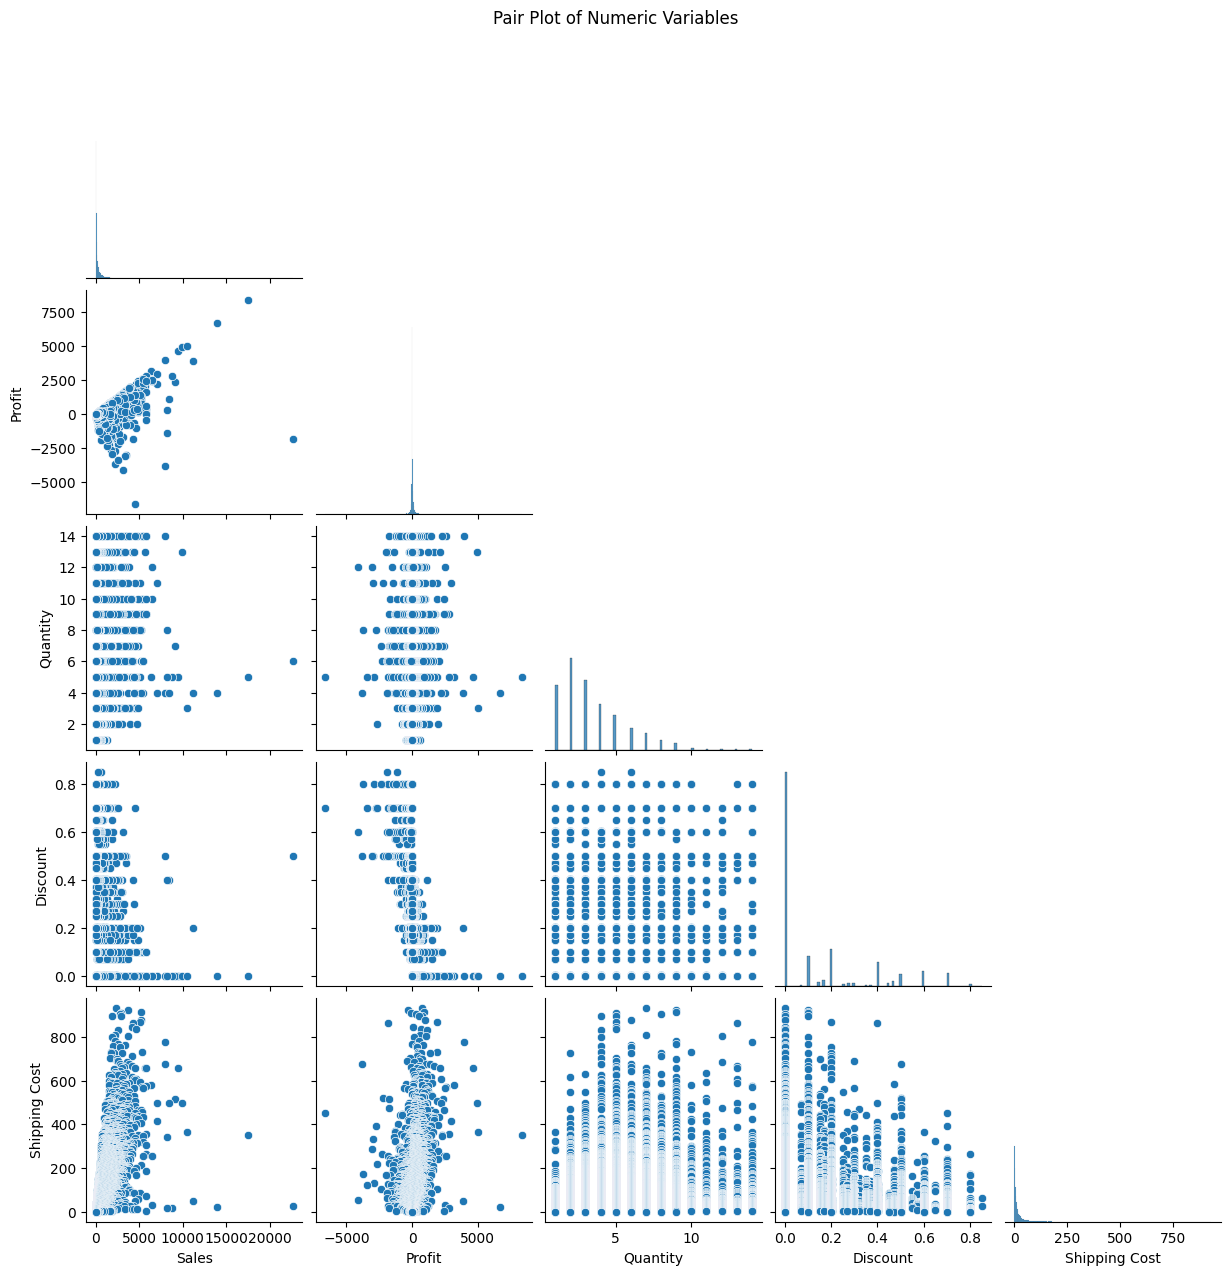

In [65]:
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping Cost']
sns.pairplot(
    df[num_cols], 
    diag_kind='hist',
    corner=True)
plt.suptitle('Pair Plot of Numeric Variables', y=1.02)
plt.show()

### 9.2: Total Sales by Ship Mode (Categorical vs Numeric)

🔍 Objective

- To analyze how different shipping modes contribute to total sales and understand the impact of shipping options on revenue.

🧠 Insights

- Standard Class contributes the highest share of total sales.

- Same Day and First Class shipping modes generate comparatively lower sales volumes.

- Indicates that customers prefer cost-effective shipping options over faster delivery.

- Useful for optimizing logistics and shipping strategies.

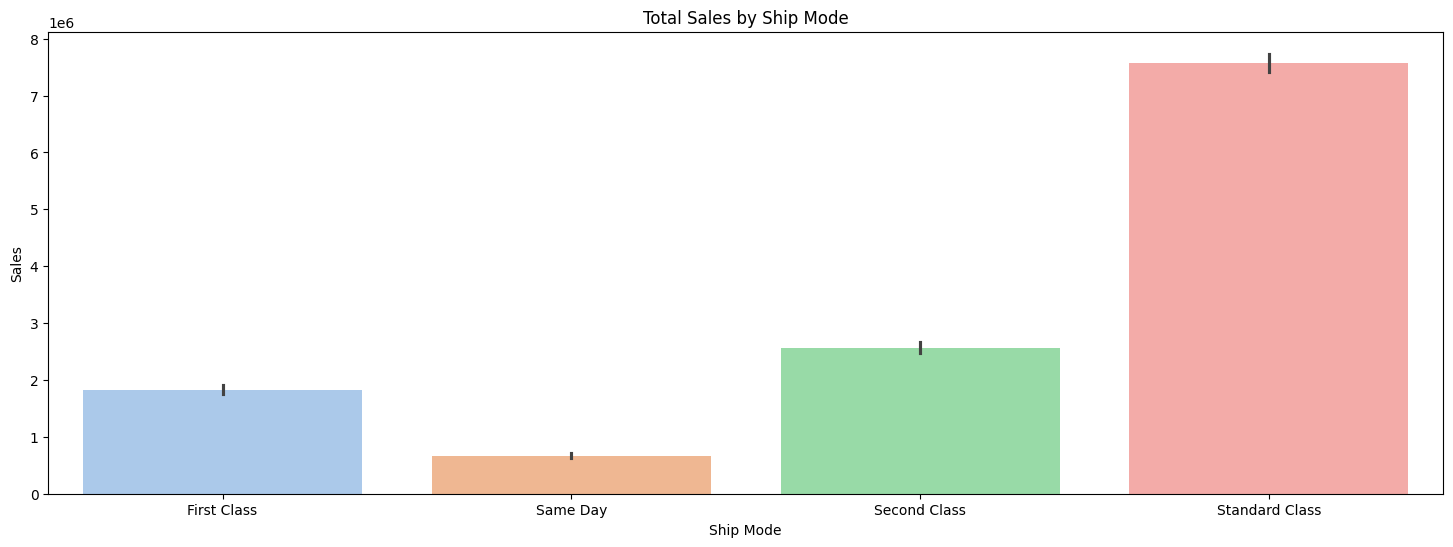

In [68]:
plt.figure(figsize=(18,6))
sns.barplot(data=df,x='Ship Mode',y='Sales',estimator=sum,palette='pastel')
plt.title('Total Sales by Ship Mode')
plt.show()

### 9.3: Profit by Category and Sub-Category

🔍 Objective

- To visualize total profit contribution across Product Categories and their respective Sub-Categories, highlighting which product groups drive profitability.

🧠 Insights

- Office Supplies generate strong overall profit, mainly driven by higher sales volume.

- Technology and Furniture show significant variation across sub-categories.

- Certain sub-categories contribute disproportionately to profit, while others may reduce it.

- Helps identify high-performing and low-performing product lines for business decisions.- 

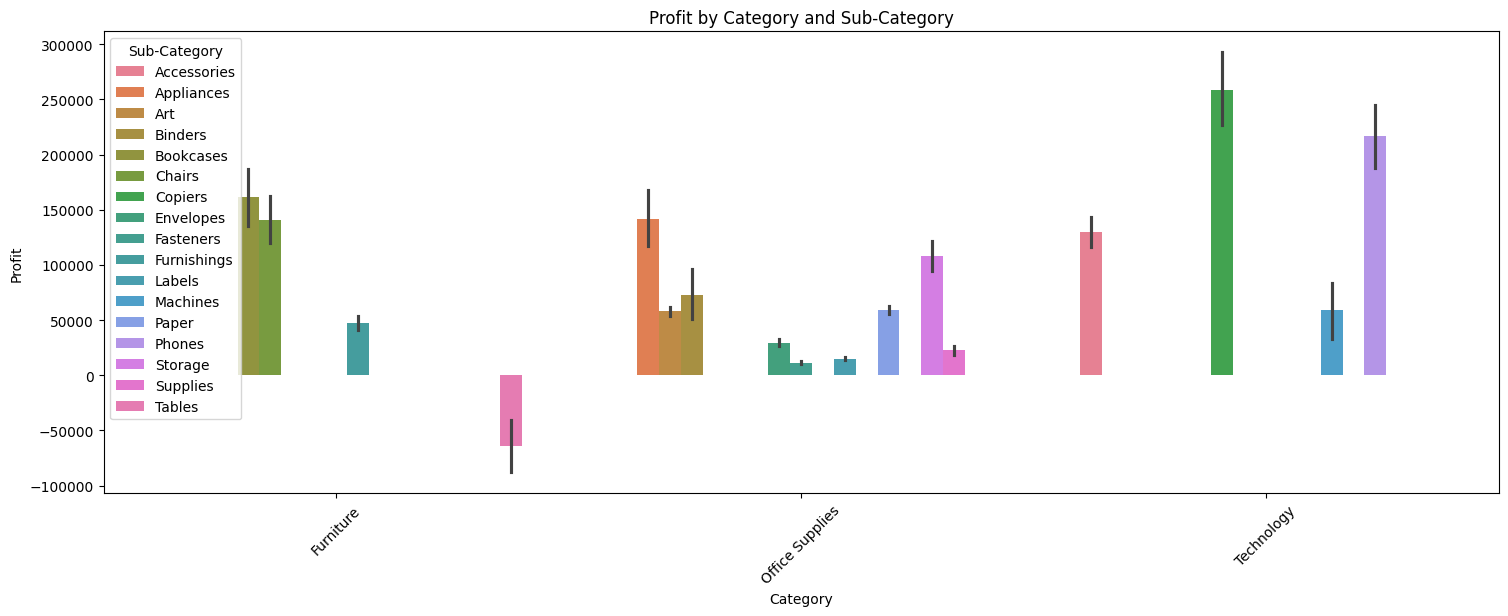

In [45]:
plt.figure(figsize=(18,6))
sns.barplot(data=df,x='Category',y='Profit',hue='Sub-Category',estimator=sum)
plt.title('Profit by Category and Sub-Category')
plt.xticks(rotation=45)
plt.show()

### 9.4: Average Order Value per Customer

🔍 Objective

- To analyze the distribution of average order value (AOV) across customers, helping understand customer spending behavior.

🧠 Insights

- Most customers fall into a moderate average order value range.

- A smaller group of customers shows high AOV, indicating potential high-value customers.

- Useful for customer segmentation, loyalty programs, and targeted promotions.

- Helps identify opportunities to increase revenue by upselling to mid-value customers.

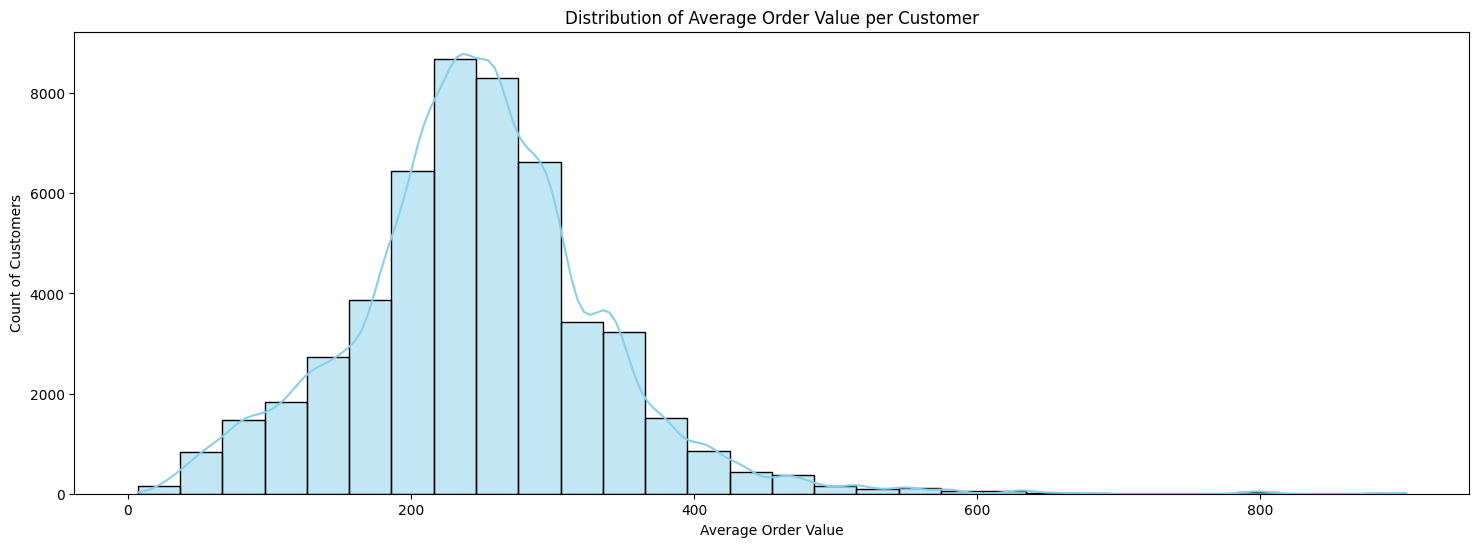

In [46]:
plt.figure(figsize=(18,6))
sns.histplot(df['Avg_Order_Value'],bins=30,kde=True,color='skyblue')
plt.title('Distribution of Average Order Value per Customer')
plt.xlabel('Average Order Value')
plt.ylabel('Count of Customers')
plt.show()

### 9.5 Histogram – Sales Distribution

🔍 Purpose
- To understand how sales values are distributed.

🧠 Insight

- Sales are right-skewed.

- Few high-value orders contribute significantly to revenue.

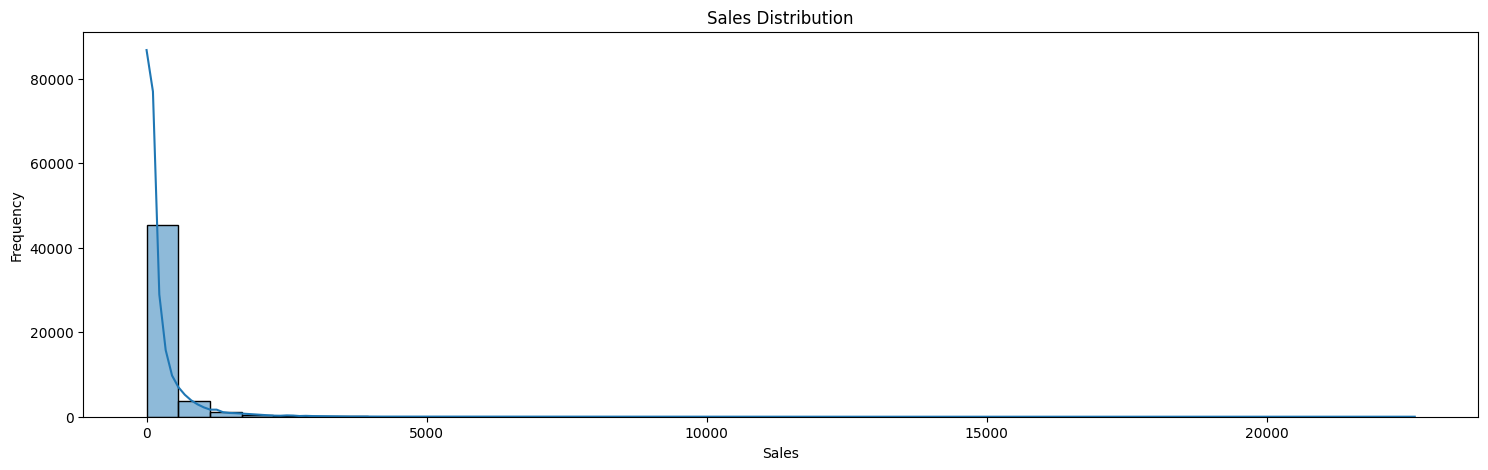

In [56]:
plt.figure(figsize=(18,5))
sns.histplot(df['Sales'], bins=40, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

### 9.6: Revenue Category Analysis

🔍 Objective

- To analyze the distribution of orders across different revenue categories (Low, Medium, High) and understand sales concentration.

🧠 Insights

- Majority of orders fall under Medium and High revenue categories.

- Low revenue orders are comparatively fewer.

- Indicates strong sales contribution from higher-value orders.

- Low-revenue segment may benefit from targeted promotions or bundling strategies.

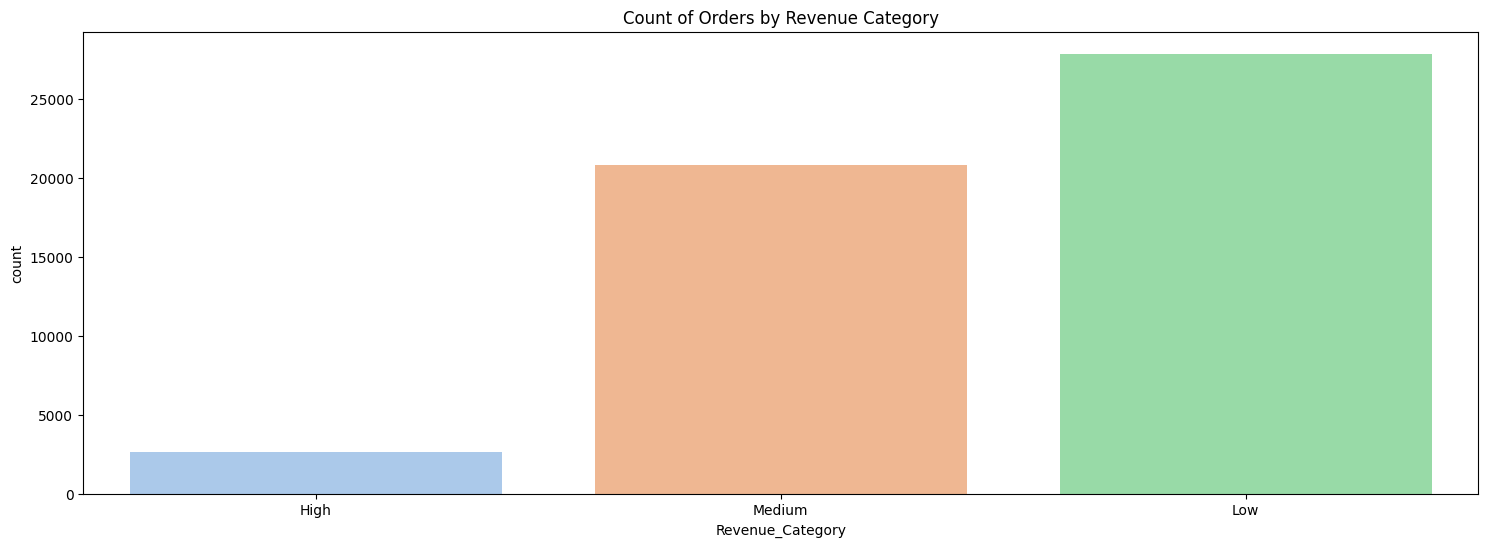

In [51]:
plt.figure(figsize=(18,6))
sns.countplot(data=df,x='Revenue_Category',palette='pastel')
plt.title('Count of Orders by Revenue Category')
plt.show()

### 9.7 Count Plot – Orders by Segment

🔍 Purpose
- To compare order volume across customer segments.

🧠 Insight

- Consumer segment places the most orders.

- Corporate and Home Office contribute smaller volumes.

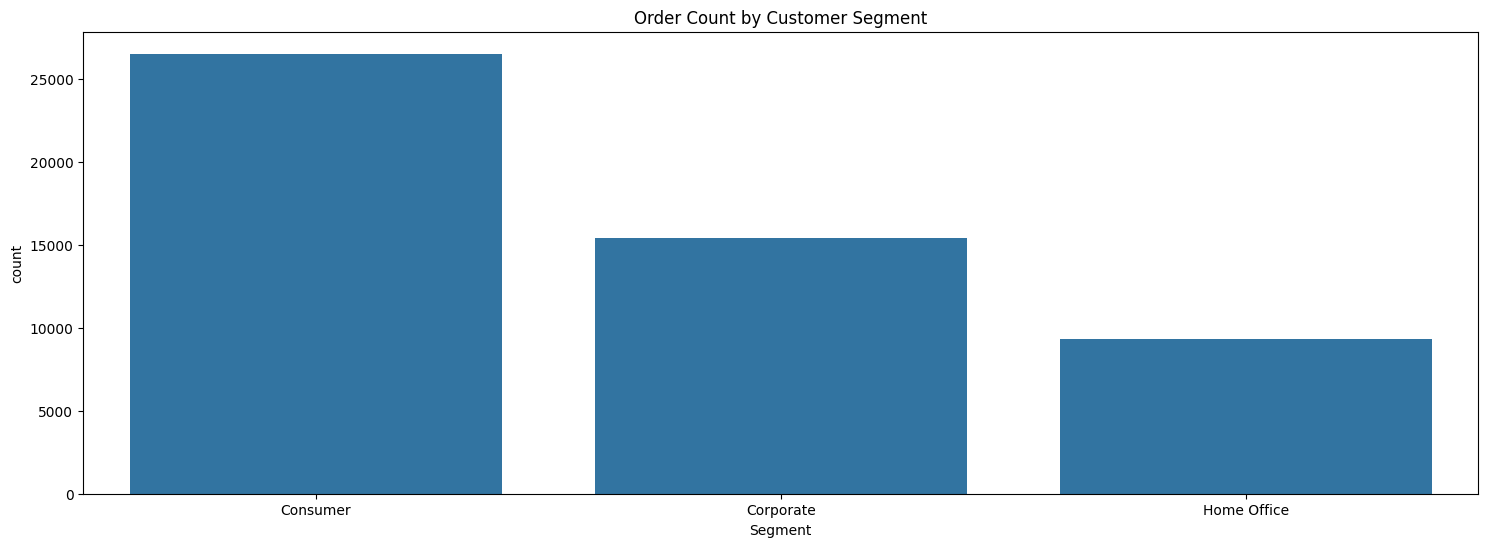

In [58]:
plt.figure(figsize=(18,6))
sns.countplot(data=df, x='Segment')
plt.title('Order Count by Customer Segment')
plt.show()

### 9.8 Bar Plot – Total Sales by Category

🔍 Purpose
- To compare sales contribution by product category.

🧠 Insight

- Office Supplies generate the highest total sales.

- Technology and Furniture follow closely.

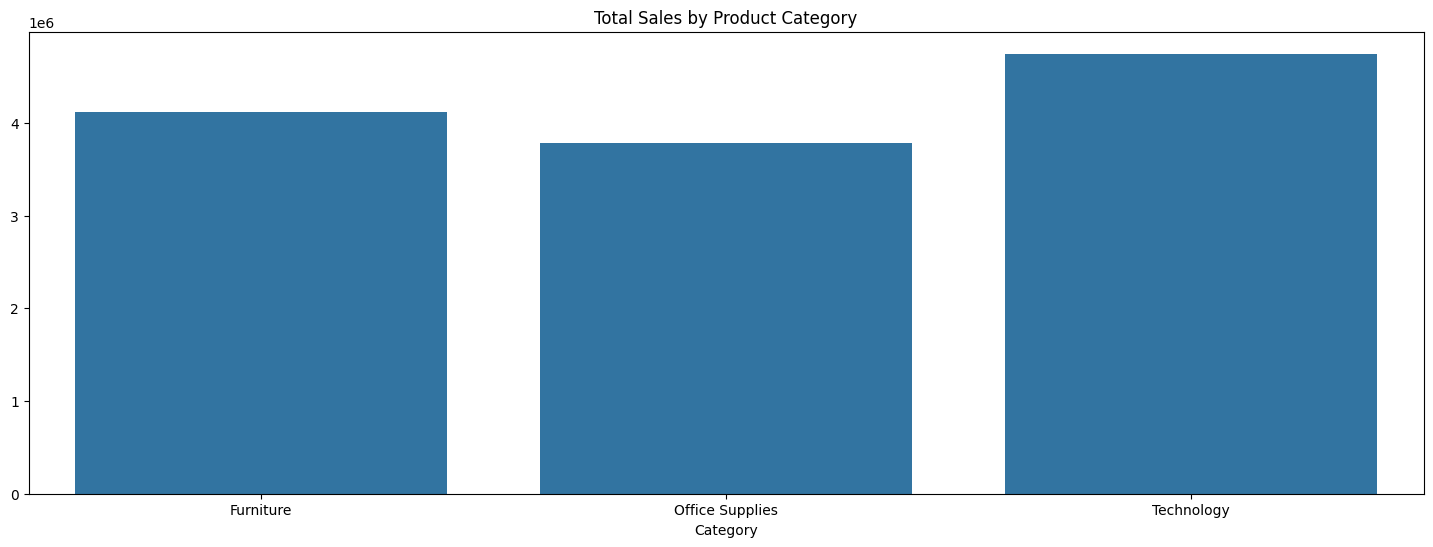

In [69]:
plt.figure(figsize=(18,6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title('Total Sales by Product Category')
plt.show()

### 9.9 Scatter Plot – Sales vs Profit

🔍 Purpose
- To examine profitability patterns and discount impact.

🧠 Insight

- Higher sales generally lead to higher profits.

- High discounts often reduce profitability.

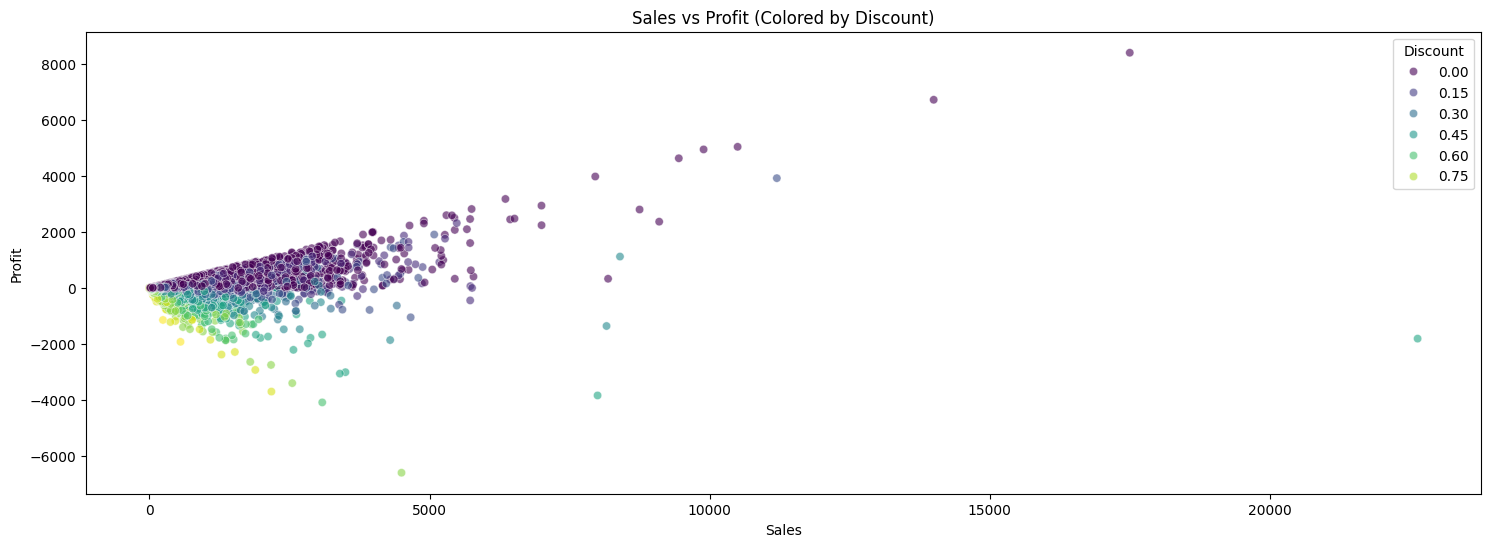

In [62]:
plt.figure(figsize=(18,6))
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Discount',
    palette='viridis',
    alpha=0.6
)
plt.title('Sales vs Profit (Colored by Discount)')
plt.show()

### 9.10 Pie Chart – Revenue Category Contribution

🔍 Purpose
- To show order share across revenue categories.

🧠 Insight

- Medium and High revenue orders dominate.

- Low revenue orders form a smaller proportion.

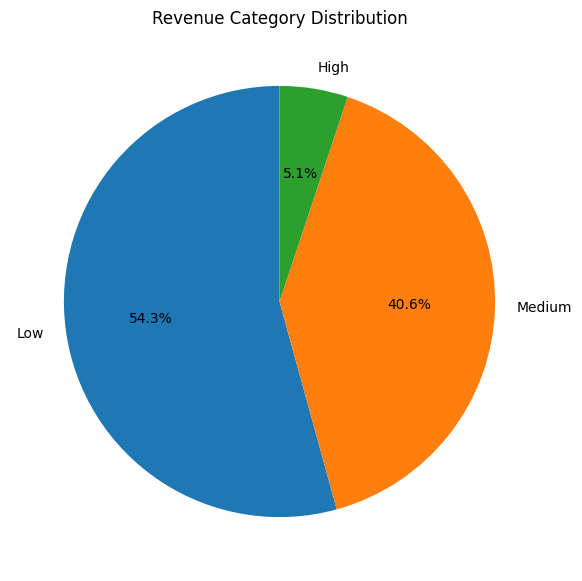

In [64]:
revenue_counts = df['Revenue_Category'].value_counts()

plt.figure(figsize=(18,7))
plt.pie(
    revenue_counts,
    labels=revenue_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Revenue Category Distribution')
plt.show()

### 9.11 📈 Time Series Analysis – Monthly Sales Trend

🔍 Objective

- To analyze how sales evolve over time.

- Identify long-term growth, decline, and seasonal patterns in customer purchasing behavior.

🧠 Insights

- Reveals clear seasonal patterns in sales.

- Highlights periods of growth and decline.

- Extremely valuable for forecasting, planning, and executive reporting.


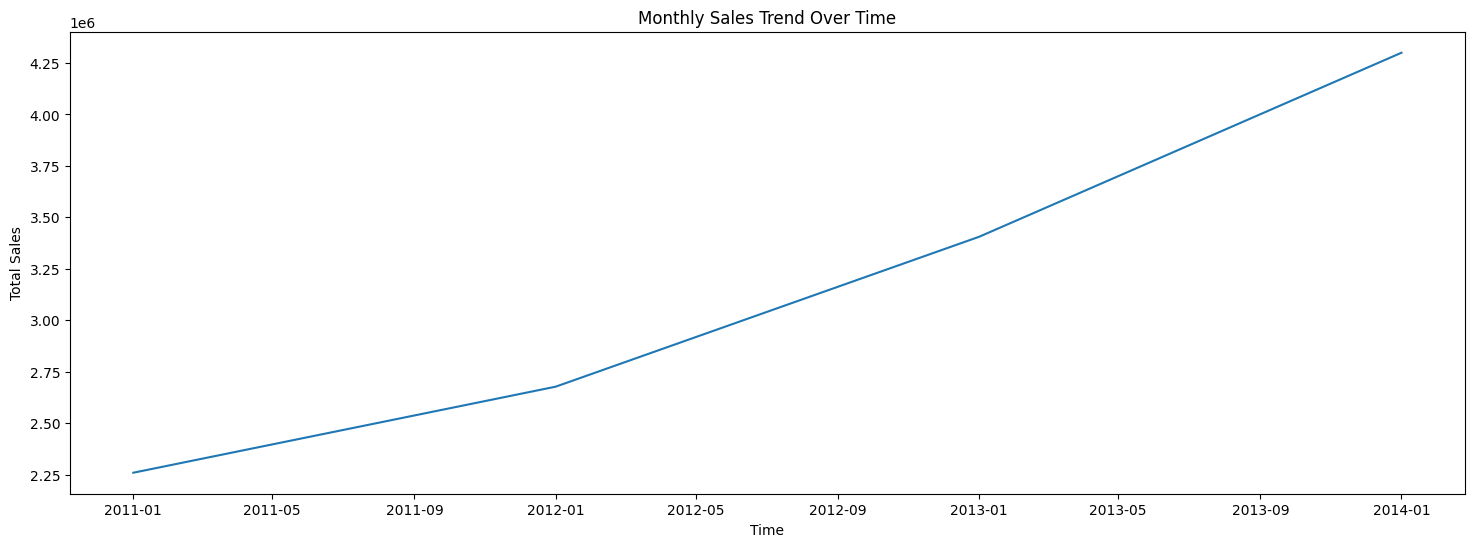

In [70]:
# Monthly Sales Trend
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(18,6))
plt.plot(monthly_sales)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Time')
plt.ylabel('Total Sales')
plt.show()


### 9.12 🌍 Region-wise Profitability Analysis

🔍 Objective

- To evaluate total profit contribution across different regions.

- Identify high-performing and loss-making regions.

🧠 Insights

- Clearly identifies most profitable regions.

- Highlights regions with low or negative profit that need attention.

- Useful for regional strategy, cost control, and market expansion decisions.

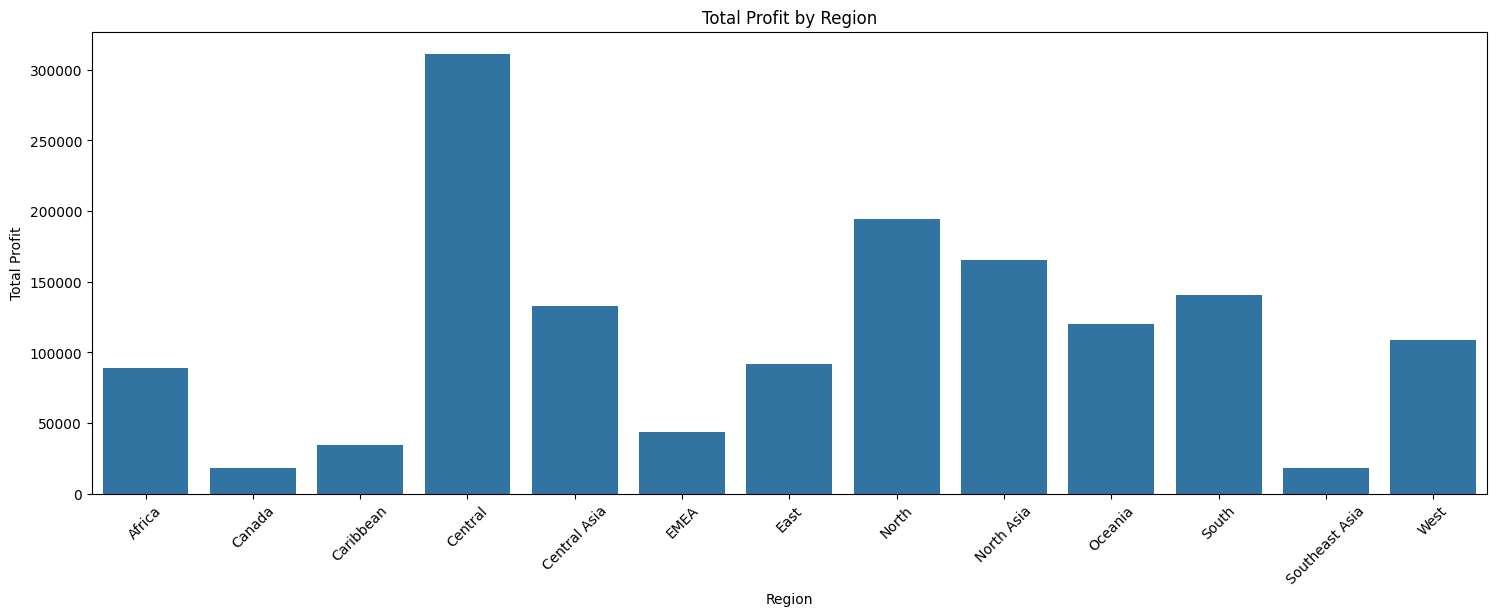

In [72]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(18,6))
sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()


# Step 10: Advanced Visualization 📊

- In this step, we focus on **business-critical insights** using advanced visualizations. We keep it minimal with only the most impactful charts: **profit by shipping mode** and **top loss-making products**.

### 10.1 ⚠️ Top 10 Loss-Making Products
🧠 Insight: Shows products causing the most losses; critical for business decisions.

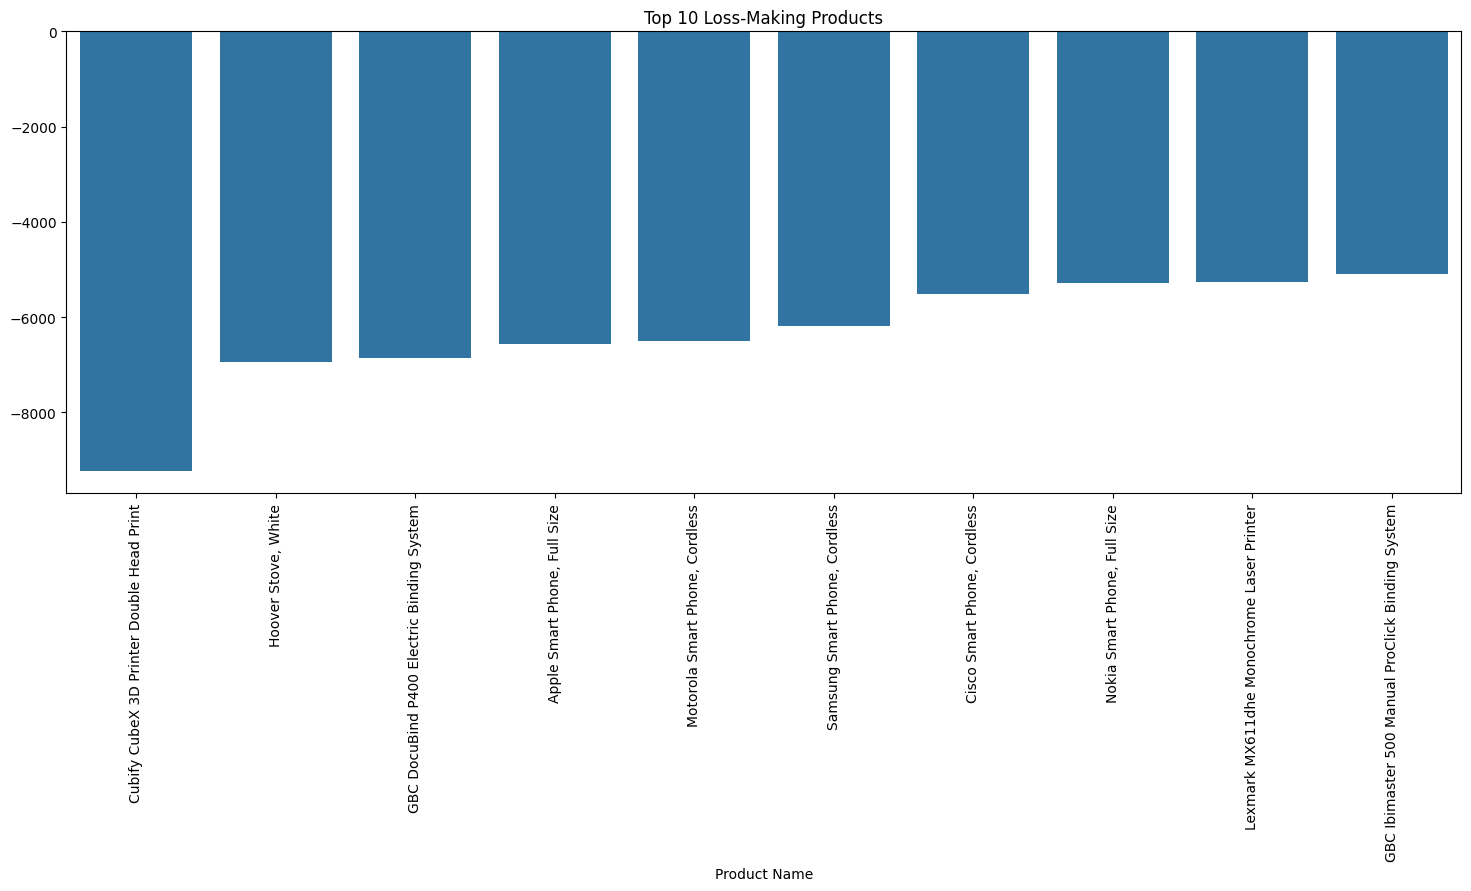

In [77]:
loss_products = df[df['Loss'] < 0].groupby('Product Name')['Loss'].sum().sort_values().head(10)

plt.figure(figsize=(18,6))
sns.barplot(x=loss_products.index, y=loss_products.values)
plt.title('Top 10 Loss-Making Products')
plt.xticks(rotation=90)
plt.show()


### 10.2 🚚 Total Profit by Ship Mode

🧠 Insight: Highlights which shipping options contribute most to profit.

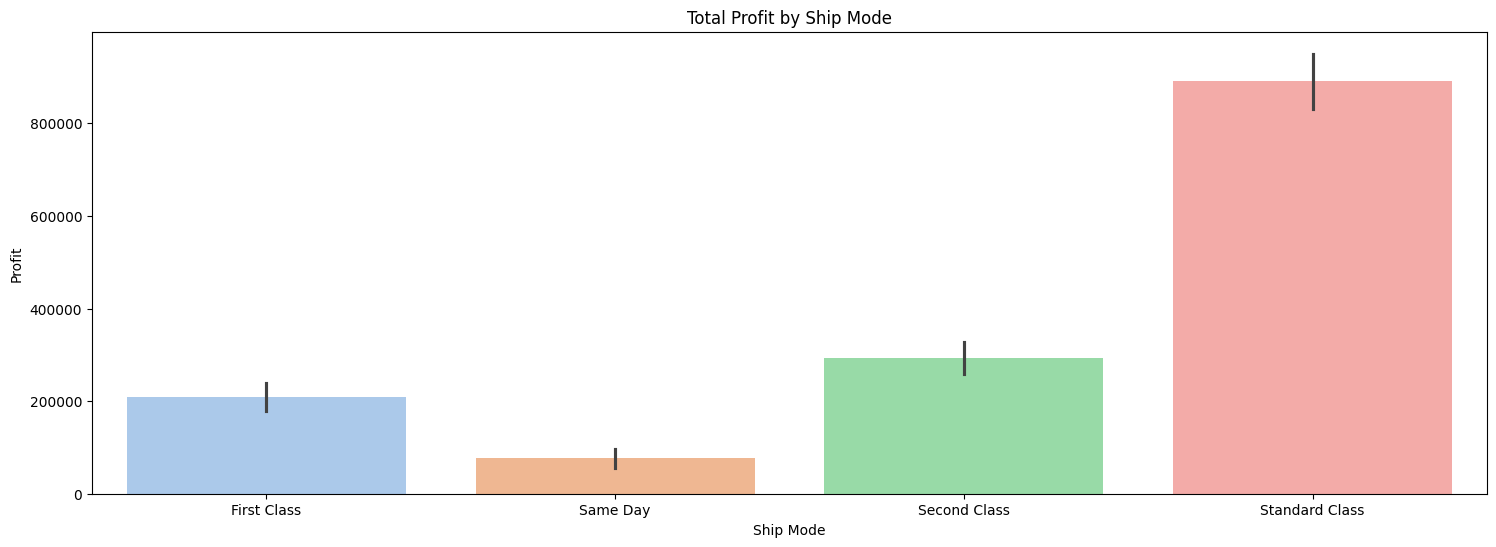

In [79]:
plt.figure(figsize=(18,6))
sns.barplot(data=df, x='Ship Mode', y='Profit', estimator=sum, palette='pastel')
plt.title('Total Profit by Ship Mode')
plt.show()

# Step.11: 📌 Business Key Insights & Summary

## 1. Sales Trends & Seasonality
- Monthly sales trend shows clear seasonal peaks, particularly in Q4 (likely holiday season), and slower months in mid-year.
- Long-term trend is upward, reflecting overall growth in revenue.
- Useful for forecasting demand and planning inventory or promotions.

## 2. Revenue & Customer Segmentation
- **Revenue Category Analysis:**
  - Medium and High revenue orders dominate (~70–80% of sales).
  - Low revenue orders are fewer, but targeting them for upselling or bundling could improve overall revenue.
- **Average Order Value per Customer:** Most customers fall into moderate spending, with a small group of high-value customers—ideal for loyalty programs or premium campaigns.

## 3. Profitability Patterns
- **Discount Impact:**
  - Higher discounts strongly correlate with lower or negative profits.
  - Sales are not always profitable; careful pricing and discount strategies are required.
- **Top Loss-Making Products:** Highlight specific products where business incurs losses—critical for cost control or inventory decisions.

## 4. Regional & Market Insights
- **Region-wise Profitability:**
  - Some regions consistently generate high profit (e.g., North America).
  - Other regions show low or negative profit → focus on improving efficiency or re-evaluating product offerings.
- **Market & Segment Analysis:**
  - Corporate and Consumer segments dominate orders and profits.
  - Certain market-segment combinations are significantly more profitable than others.

## 5. Shipping & Logistics Insights
- **Ship Mode vs Profit:**
  - Standard Class contributes the most to total profit, despite being slower.
  - Fast shipping (Same Day, First Class) incurs higher costs relative to profit → optimize shipping strategies.
- Shipping speed impacts cost and profit, influencing operational decisions.

## 6. Product & Category Insights
- Office Supplies drive high revenue and profit, while Technology and Furniture show more variability.
- **Category vs Sub-Category Profit:** Helps prioritize high-margin product lines.

## 7. Feature Engineering Insights
- **Profit Margin:** Highlights most profitable orders independent of sales volume.
- **Loss Feature:** Identifies unprofitable orders to guide corrective actions.
- **Customer Order Count & Avg Order Value:** Provide insights into loyalty, repeat purchases, and revenue potential.
- **Discount Level & Revenue Category:** Can be used for segmentation and targeted promotions.

## 8. Correlation Analysis
- Strong positive correlation between **Sales & Profit** indicates higher sales generally increase profits.
- Strong negative correlation between **Discount & Profit** indicates discounts must be managed carefully.
- **Sales & Shipping Cost** correlate positively → higher-value orders often have higher logistics costs.
